In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

Matplotlib is building the font cache; this may take a moment.


In [2]:
dataset_path = "../datasets/raw/chest_xray"

print(os.listdir(dataset_path))

['.DS_Store', 'test', 'train', 'val']


In [3]:
for split in ["train", "test", "val"]:
    print(f"\n{'='*30}")
    print(f"{split.upper()} DATASET")
    print("="*30)

    split_path = os.path.join(dataset_path, split)

    total = 0

    for cls in os.listdir(split_path):
        class_path = os.path.join(split_path, cls)

        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            total += count
            print(f"{cls:<12} : {count}")

    print(f"Total Images : {total}")


TRAIN DATASET
NORMAL       : 1342
PNEUMONIA    : 3876
Total Images : 5218

TEST DATASET
NORMAL       : 234
PNEUMONIA    : 390
Total Images : 624

VAL DATASET
NORMAL       : 9
PNEUMONIA    : 9
Total Images : 18


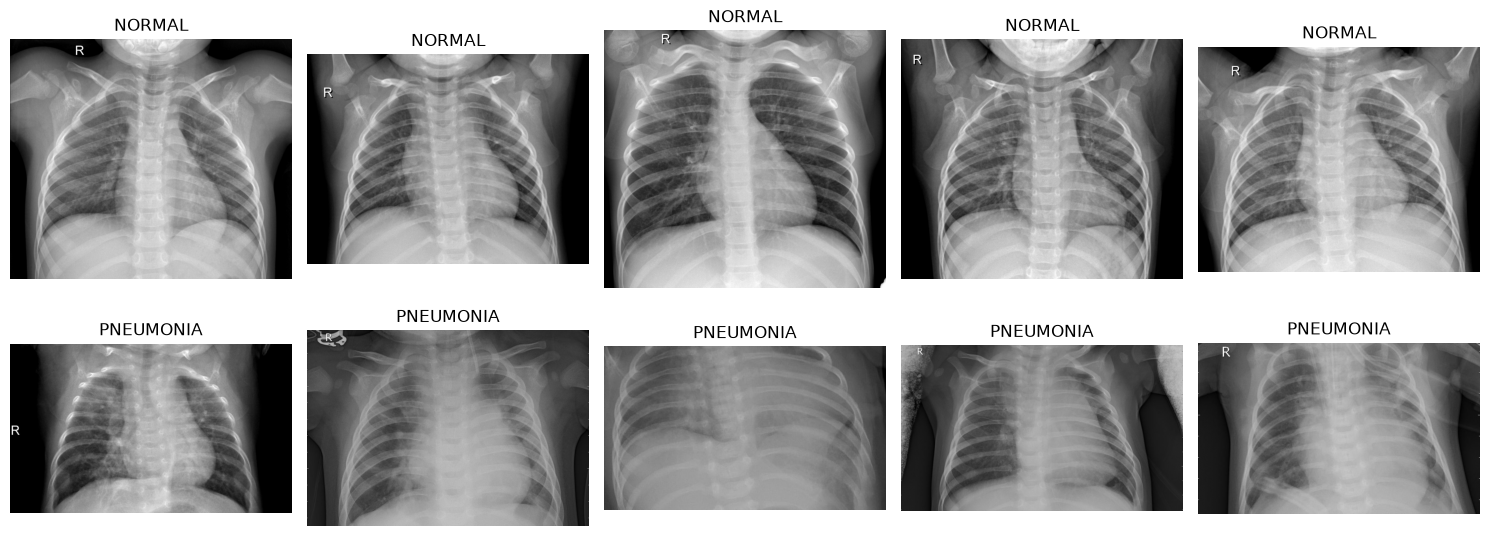

In [4]:
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

classes = ["NORMAL", "PNEUMONIA"]

for row, cls in enumerate(classes):

    folder = os.path.join(dataset_path, "train", cls)

    images = os.listdir(folder)

    sample_images = random.sample(images, 5)

    for col, img_name in enumerate(sample_images):

        img_path = os.path.join(folder, img_name)

        img = Image.open(img_path)

        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [8]:
sample = os.path.join(dataset_path, "train", "NORMAL")

image_files = [
    f for f in os.listdir(sample)
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
]

print("First 5 image files:", image_files[:5])

img_name = image_files[0]

img = Image.open(os.path.join(sample, img_name))

print("Image Size:", img.size)
print("Image Mode:", img.mode)

First 5 image files: ['IM-0115-0001.jpeg', 'IM-0117-0001.jpeg', 'IM-0119-0001.jpeg', 'IM-0122-0001.jpeg', 'IM-0125-0001.jpeg']
Image Size: (2090, 1858)
Image Mode: L


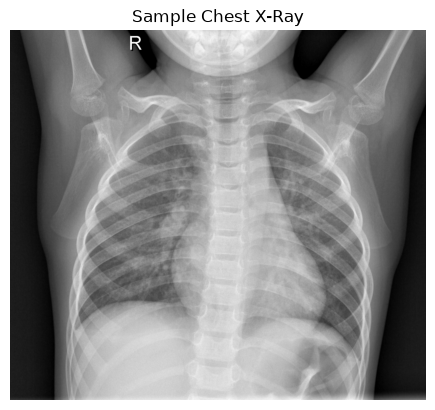

In [9]:
import matplotlib.pyplot as plt

plt.imshow(img, cmap="gray")
plt.title("Sample Chest X-Ray")
plt.axis("off")
plt.show()

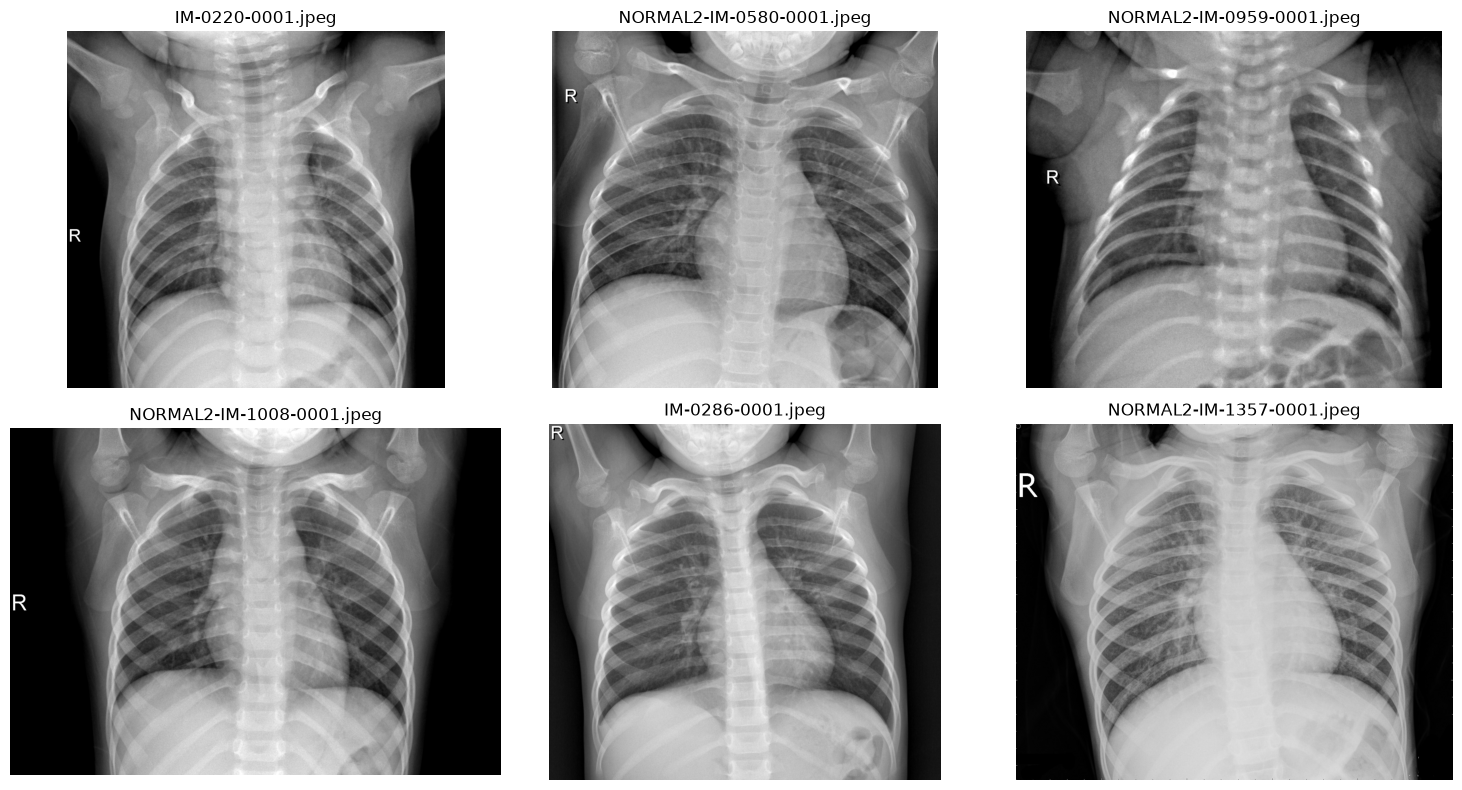

In [10]:
import random

sample_images = random.sample(image_files, 6)

plt.figure(figsize=(15,8))

for i, image_name in enumerate(sample_images):
    image = Image.open(os.path.join(sample, image_name))

    plt.subplot(2,3,i+1)
    plt.imshow(image, cmap="gray")
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} Dataset")

    split_path = os.path.join(dataset_path, split)

    for category in os.listdir(split_path):
        category_path = os.path.join(split_path, category)

        if os.path.isdir(category_path):
            count = len([
                f for f in os.listdir(category_path)
                if f.lower().endswith((".jpeg", ".jpg", ".png"))
            ])
            print(f"{category}: {count}")


TRAIN Dataset
NORMAL: 1341
PNEUMONIA: 3875

VAL Dataset
NORMAL: 8
PNEUMONIA: 8

TEST Dataset
NORMAL: 234
PNEUMONIA: 390


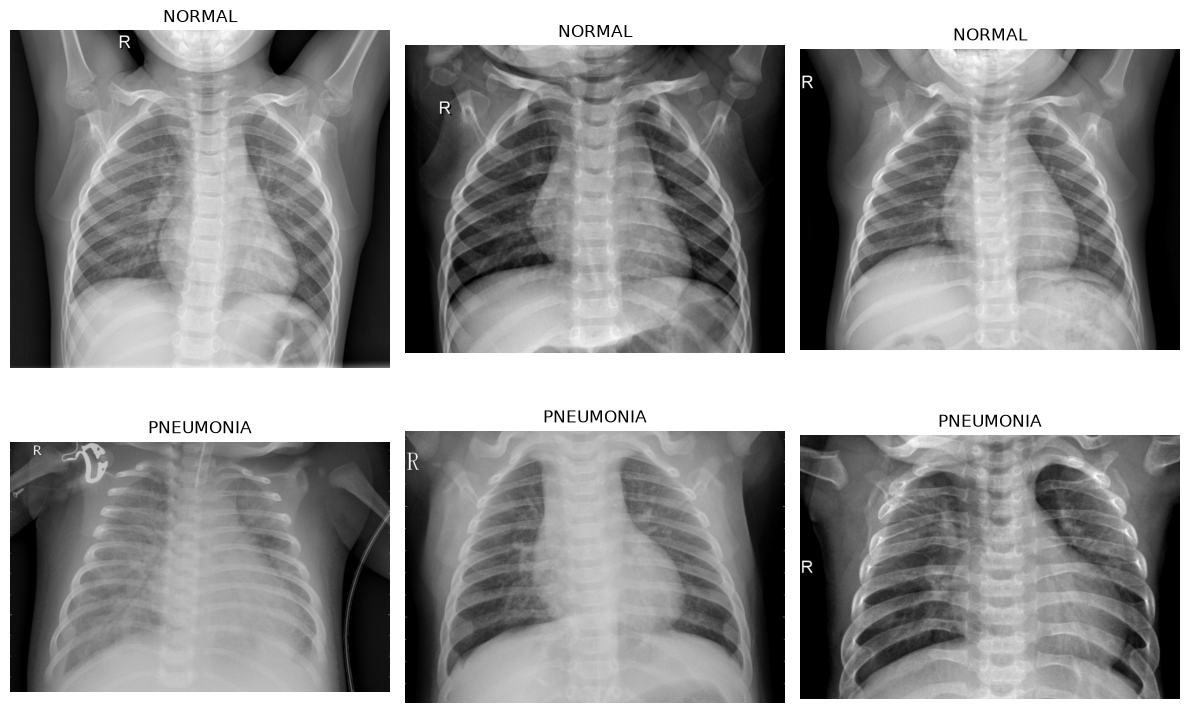

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

classes = ["NORMAL", "PNEUMONIA"]

for row, cls in enumerate(classes):
    folder = os.path.join(dataset_path, "train", cls)

    image_files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpeg", ".jpg", ".png"))
    ]

    for col in range(3):
        img = Image.open(os.path.join(folder, image_files[col]))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()